# LSTM: normalised features

Same LSTM as `reeval_lstm.ipynb` (64-64, Dense 16, Adam 1e-3, batch 15, 20 epochs, no validation data), with the preprocessing steps below.

**Preprocessing steps** (cumulative, see `src/reeval_normalized.py`):

| Step | What changes |
|---|---|
| S0 | Thesis features, unchanged. Result taken from `results/reeval/`. |
| S1 | Undetected keypoints (x = y = 0) filled by linear interpolation over time, so they no longer create fake jumps. |
| S2 | S1, then coordinates divided by the recording's median torso length (neck to mid-hip), so displacements no longer depend on body size or distance from the camera. |
| S3 | S2, then each keypoint's dx and dy standardised with the training fold's mean and SD (neural networks only). |

Everything else is identical to the `reeval_*` notebooks: the 41 recordings, 6 classes, the same 15 recording-level splits, the same model settings. Only the input changes, so each step's effect can be read off directly.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc
import reeval_normalized as rn

rn.use_results_dir()
records = rc.load_recordings()

## What the preprocessing does to the data

In [2]:
X_raw, _, _ = rn.displacement_windows(records, interpolate=False, scale=False)
X_s1, _, _ = rn.displacement_windows(records, interpolate=True, scale=False)
torso = pd.Series([rn.torso_length(r["frames"]) for r in records])
pd.DataFrame({
    "windows with a jump > 100 px": [f"{rn.spike_share(X_raw):.0%}", f"{rn.spike_share(X_s1):.0%}"],
    "median |displacement| (px)": [f"{np.median(np.abs(X_raw)):.2f}", f"{np.median(np.abs(X_s1)):.2f}"],
}, index=["S0 raw", "S1 interpolated"]).assign(**{"torso length px (min / median / max)": f"{torso.min():.0f} / {torso.median():.0f} / {torso.max():.0f}"})

,windows with a jump > 100 px,median |displacement| (px),torso length px (min / median / max)
S0 raw,45%,2.55,93 / 107 / 117
S1 interpolated,6%,2.55,93 / 107 / 117


## Model (same settings as the thesis re-evaluation)

In [3]:
import keras
from keras import layers

print("keras", keras.__version__)


def build_lstm():
    model = keras.Sequential([
        keras.Input(shape=(rc.WINDOW, 50)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.5),
        layers.LSTM(64, kernel_regularizer="l2"),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu", kernel_regularizer="l2", bias_regularizer="l2"),
        layers.Dense(len(rc.CLASSES), activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def make_fit_predict(standardise):
    def fit_predict(X_train, y_train, groups_train, X_test, seed):
        if standardise:
            scaler = rn.KeypointScaler().fit(X_train)
            X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
        keras.utils.set_random_seed(seed)
        model = build_lstm()
        model.fit(X_train.reshape(len(X_train), rc.WINDOW, -1), rc.one_hot(y_train), batch_size=15, epochs=20, verbose=0)
        proba = model.predict(X_test.reshape(len(X_test), rc.WINDOW, -1), verbose=0)
        return np.array(rc.CLASSES)[proba.argmax(axis=1)]
    return fit_predict

keras 3.15.1


## Results per step

In [4]:
results = {"S0": rn.load_raw_result("lstm")}
STEP_FLAGS = {"S1": (True, False, False), "S2": (True, True, False), "S3": (True, True, True)}

for step in ['S1', 'S2', 'S3']:
    interpolate, scale, standardise = STEP_FLAGS[step]
    X, y, groups = rn.displacement_windows(records, interpolate=interpolate, scale=scale)
    results[step] = rc.evaluate(
        make_fit_predict(standardise), X, y, groups, rc.recording_splits(groups, records),
        model="LSTM", variant=f"{step}: {rn.STEPS[step]}", split="recording-level 5-fold × 3",
        features="displacement windows (25 × 50)", params="LSTM 64-64, Dense 16, Adam 1e-3, batch 15, 20 epochs",
    )
    rc.save_results(results[step], f"lstm_{step}")

rc.summary_table(list(results.values()))

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,LSTM,S0: thesis features (raw),recording-level 5-fold × 3,121,15,77.3% ± 10.9%,77.6% ± 9.3%,77.3% ± 8.9%,27.1%
1,LSTM,S1: missing-joint interpolation,recording-level 5-fold × 3,121,15,91.4% ± 6.4%,90.4% ± 8.4%,93.4% ± 7.9%,27.1%
2,LSTM,S2: S1 + torso-length scaling,recording-level 5-fold × 3,121,15,45.6% ± 7.9%,34.2% ± 7.8%,47.8% ± 10.6%,27.1%
3,LSTM,S3: S2 + standardisation,recording-level 5-fold × 3,121,15,91.3% ± 7.5%,89.4% ± 9.5%,93.5% ± 9.2%,27.1%


Change against S0 on the same splits (a split counts as better if accuracy is higher):

In [5]:
last = list(results)[-1]
s0 = np.array([f["accuracy"] for f in results["S0"]["folds"]])
rows = []
for step in list(results)[1:]:
    acc = np.array([f["accuracy"] for f in results[step]["folds"]])
    diff = acc - s0
    rows.append({"step": step, "mean change vs S0": f"{diff.mean():+.1%}", "better / equal / worse splits": f"{(diff > 0).sum()} / {(diff == 0).sum()} / {(diff < 0).sum()}"})
pd.DataFrame(rows)

,step,mean change vs S0,better / equal / worse splits
0,S1,+14.1%,14 / 1 / 0
1,S2,-31.8%,0 / 0 / 15
2,S3,+13.9%,13 / 0 / 2


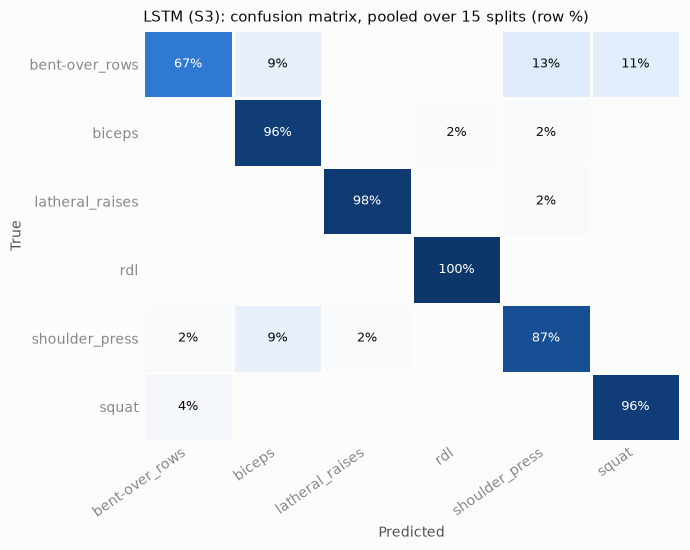

In [6]:
rc.plot_confusion(results[last], f"LSTM ({last}): confusion matrix, pooled over 15 splits (row %)", f"lstm_{last}_confusion.png");